In [61]:
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import numpy as np
import pandas as pd
import seaborn as sns
import xarray as xr

from afolu.defs.assets.constants import LABEL_LIST

In [2]:
sent_path = Path("./pred")

In [3]:
mats, cities = [], []
for path in (sent_path / "transitions").glob("*.csv"):
    df = pd.read_csv(path).set_index("time_period")
    df.columns = df.columns.str.replace("pij_lndu_", "").str.split("_to_", expand=True)
    df.columns.names = ["start", "end"]
    full_cols = pd.MultiIndex.from_product(
        [LABEL_LIST, LABEL_LIST], names=["start", "end"]
    )
    df = df.reindex(columns=full_cols, fill_value=0)

    mats.append(df.to_numpy().reshape(len(df), len(LABEL_LIST), len(LABEL_LIST)))
    cities.append(path.stem)

arr = xr.DataArray(
    np.stack(mats, axis=0),
    dims=["city", "time_period", "start", "end"],
    coords={
        "city": pd.Index(cities),
        "time_period": df.index,
        "start": pd.Index(LABEL_LIST),
        "end": pd.Index(LABEL_LIST),
    },
)

In [41]:
mats, cities = [], []
for path in (sent_path / "areas").glob("*.csv"):
    df_area = pd.read_csv(path).set_index("label").transpose()
    df_area.index.name = "time_period"
    df_area = df_area.reindex(columns=pd.Index(LABEL_LIST), fill_value=0).multiply(
        10_000
    )

    mats.append(df_area.to_numpy())
    cities.append(path.stem)

arr_area = xr.DataArray(
    np.stack(mats, axis=0),
    dims=["city", "time_period", "label"],
    coords={
        "city": pd.Index(cities),
        "time_period": df_area.index.astype(int),
        "label": pd.Index(LABEL_LIST),
    },
    name="area",
)

arr_area_frac = arr_area / arr_area.sum(dim="label")

In [75]:
arr_transition = (arr / arr.sum(dim="end")).fillna(0).rename("transition_probability")

zero_rows = arr_transition.sum(dim="end") == 0
diagonal = arr_transition["start"] == arr_transition["end"]
mask = zero_rows & diagonal
arr_transition = arr_transition.where(~mask, 1)

# Plots

## Area

Since there is a high variation between the surface area of metropolitan zones, it is more convenient to compare land use *area fractions*. This is just the land use area divided by the total metropolitan zone area.

The following plot showcases how land use has changed for two periods in time: the first available year (2000) and the last one (2022), for all 69 metropolitan zones.

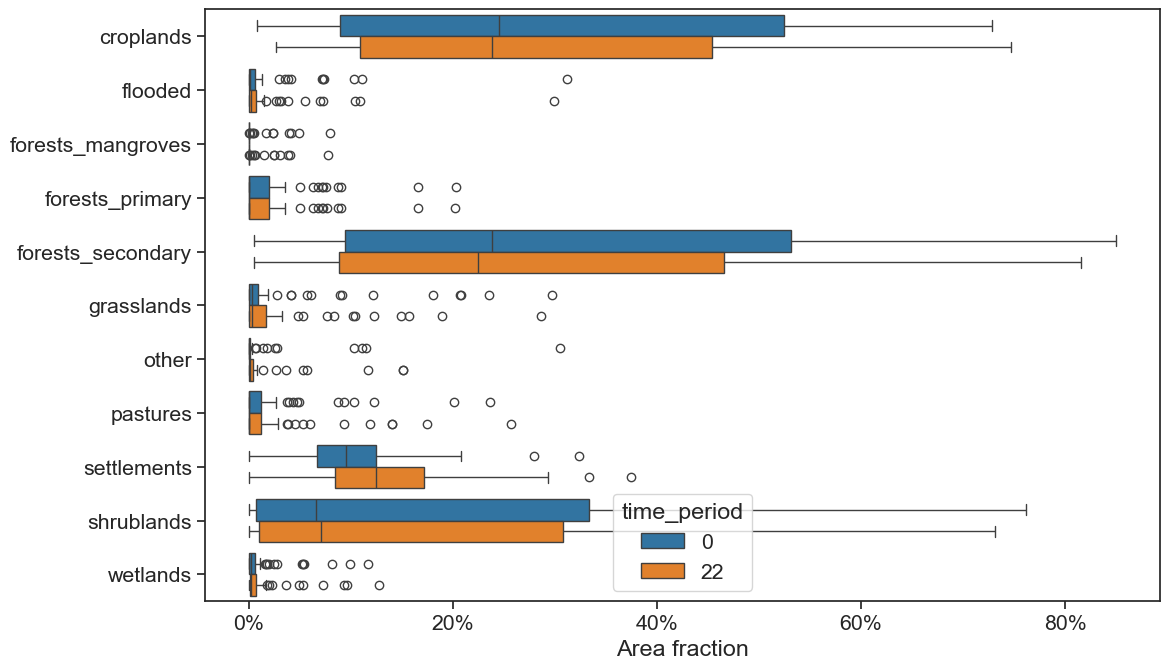

In [126]:
sns.set_theme(font_scale=1.4, style="ticks")

fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(
    arr_area_frac.sel(time_period=[0, 22]).to_dataframe().reset_index(),
    y="label",
    x="area",
    ax=ax,
    hue="time_period",
    palette="tab10",
)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel("Area fraction")
ax.set_ylabel("")
fig.tight_layout()

Even though the spread for some land use types is quite large, on average we can observe the following effects:

* Cropland and secondary forests area has decreased
* Settlements area has increased

To reduce the spread between observations, the next plot uses instead the *difference* between both years, in percentage points:

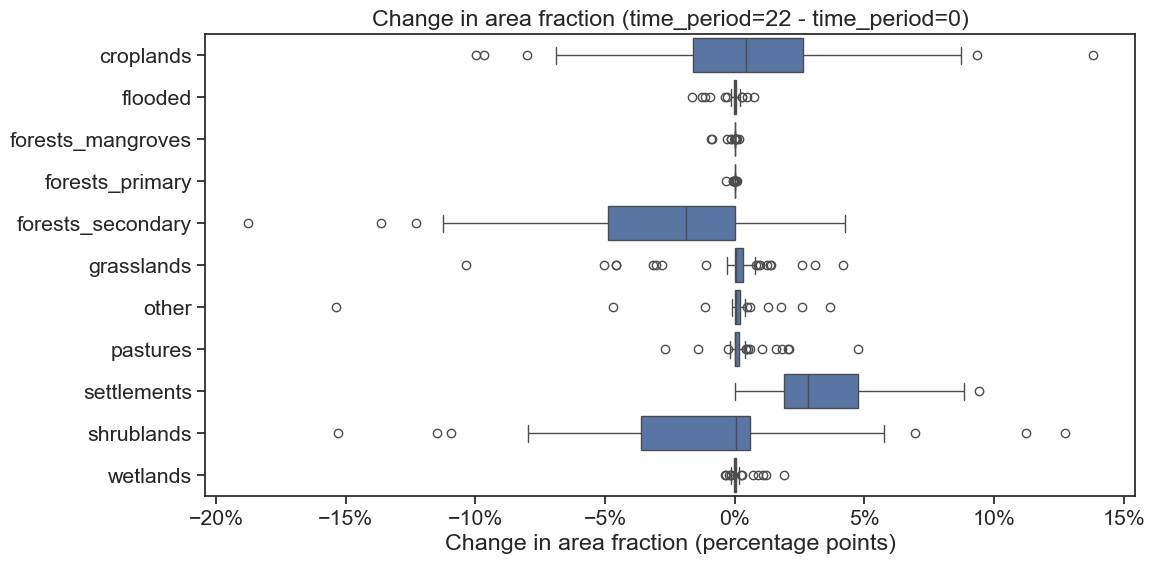

In [209]:
sns.set_theme(font_scale=1.4, style="ticks")

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(
    (arr_area_frac.sel(time_period=22) - arr_area_frac.sel(time_period=0))
    .to_dataframe()
    .reset_index(),
    y="label",
    x="area",
    ax=ax,
)
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
ax.set_title("Change in area fraction (time_period=22 - time_period=0)")
ax.set_xlabel("Change in area fraction (percentage points)")
_ = ax.set_ylabel("")

Finally, we can plot the evolution of the mean land use fraction for each land use type:

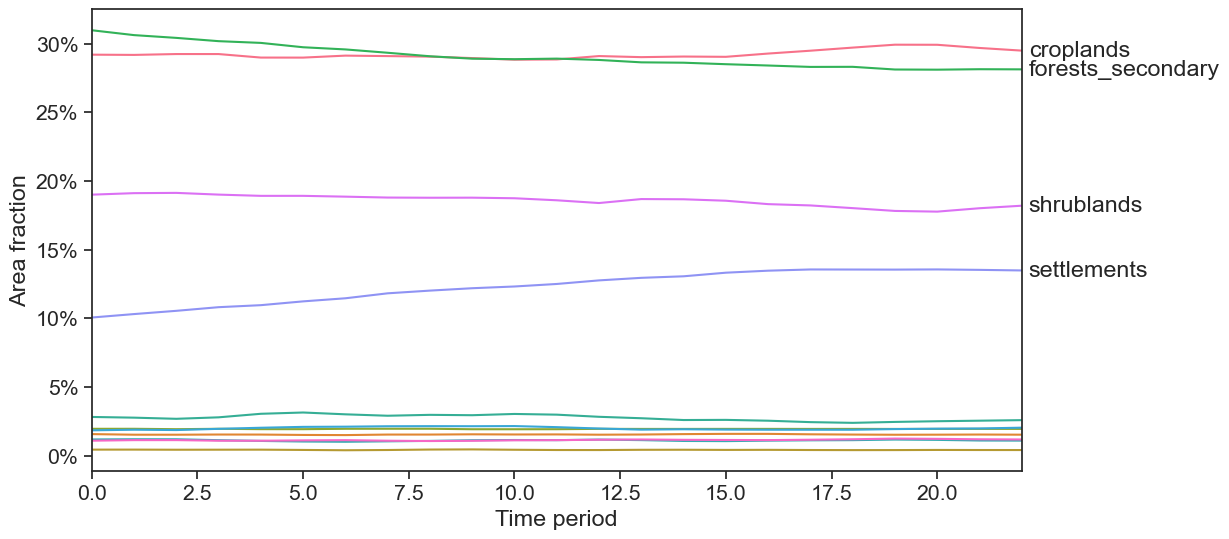

In [195]:
sns.set_theme(font_scale=1.4, style="ticks")
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    arr_area_frac.to_dataframe().reset_index(),
    x="time_period",
    y="area",
    hue="label",
    ax=ax,
    legend=False,
    errorbar=None,
    estimator="mean",
)

for label in ["croplands", "forests_secondary", "settlements", "shrublands"]:
    ax.annotate(
        label,
        xy=(
            arr_area_frac.time_period[-1],
            arr_area_frac.sel(label=label).mean(dim="city")[-1],
        ),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
    )

ax.set_xlim(0, 22)
ax.set_xlabel("Time period")
ax.set_ylabel("Area fraction")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))

This visualization has the disadvantage of not showing the spread of values, which may lead to incorrect conclusions. To remedy this, we generate a separate plot for each of the four most common land use types. The shaded regions represent the inter-quartile range.

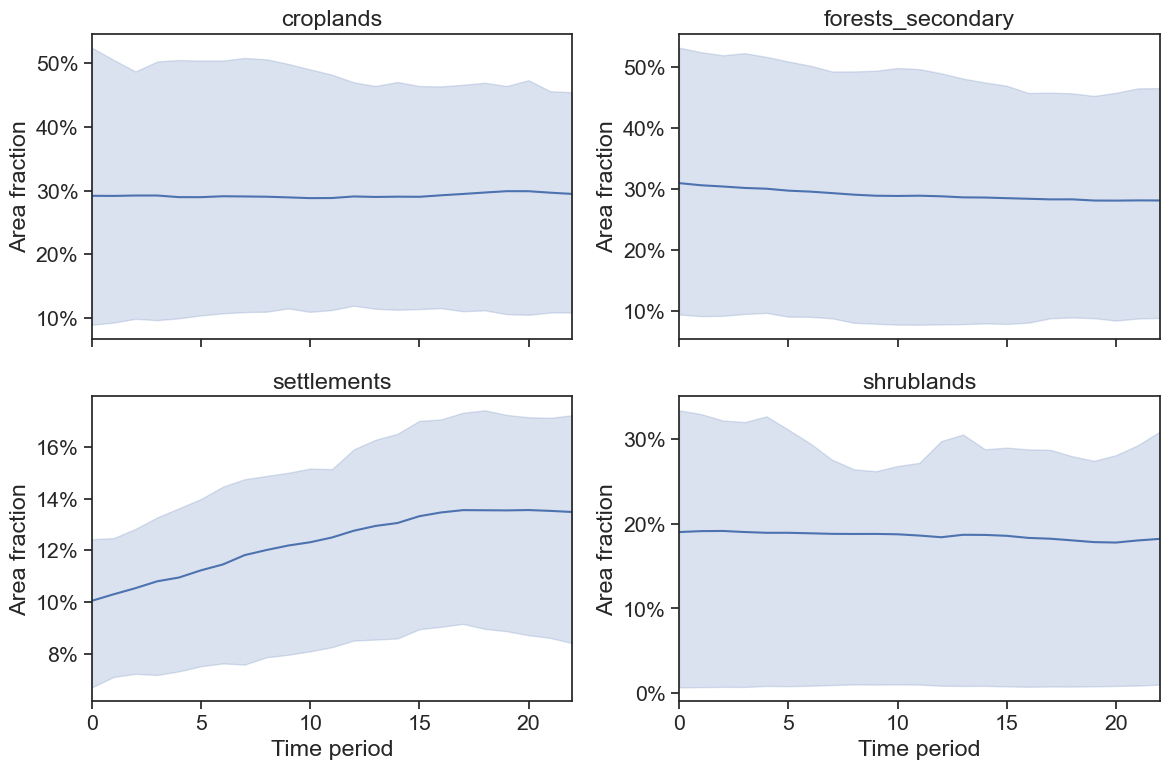

In [196]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True, sharey=False)
for ax, label in zip(
    axes.flatten(),
    ["croplands", "forests_secondary", "settlements", "shrublands"],
    strict=True,
):
    sns.lineplot(
        arr_area_frac.sel(label=label).to_dataframe().reset_index(),
        x="time_period",
        y="area",
        ax=ax,
        legend=False,
        errorbar=("pi", 50),
        estimator="mean",
    )
    ax.set_title(label)
    ax.set_xlim(0, 22)
    ax.set_xlabel("Time period")
    ax.set_ylabel("Area fraction")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
fig.tight_layout()

## Transition probabilities

In the same manner as the previous section, we plot the probability of turning into a settlement for the first and last years available. We omit the settlement-to-settlement "transition", since it has a much larger magnitude than all others, and is not of much interest for our purposes.

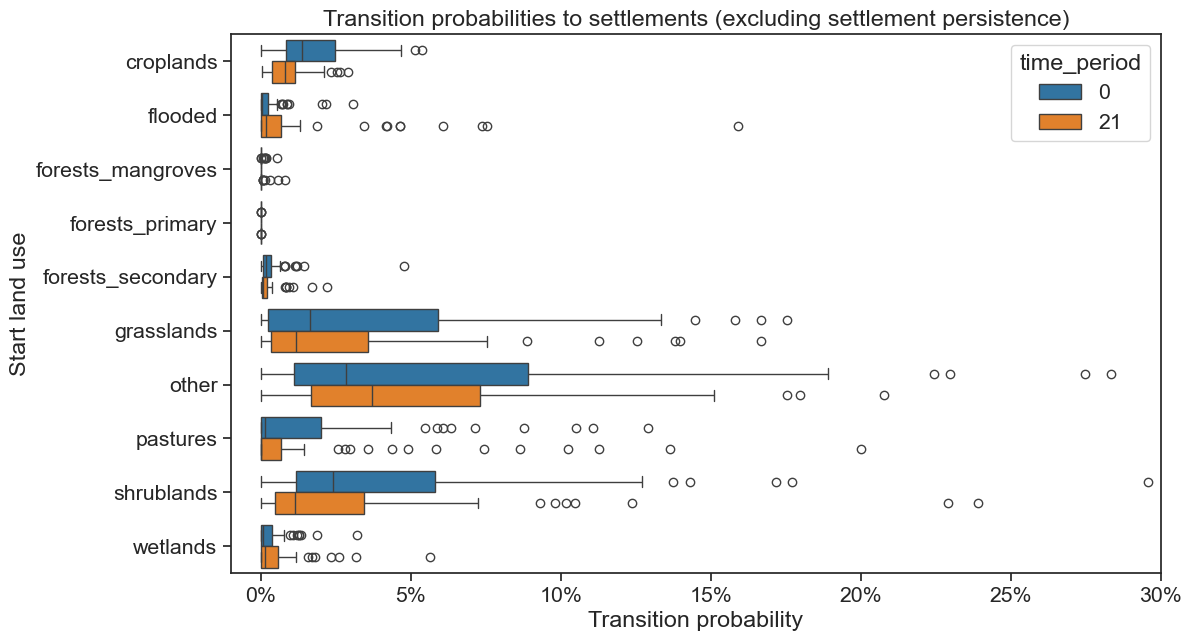

In [241]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(
    arr_transition.sel(end="settlements", time_period=[0, 21])
    .drop_sel(start="settlements")
    .to_dataframe()
    .reset_index(),
    x="transition_probability",
    y="start",
    hue="time_period",
    palette="tab10",
)
ax.set_xlim(-0.01, 0.3)
ax.set_xlabel("Transition probability")
ax.set_ylabel("Start land use")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
_ = ax.set_title(
    "Transition probabilities to settlements (excluding settlement persistence)"
)

Then, we plot the change in transition probability:

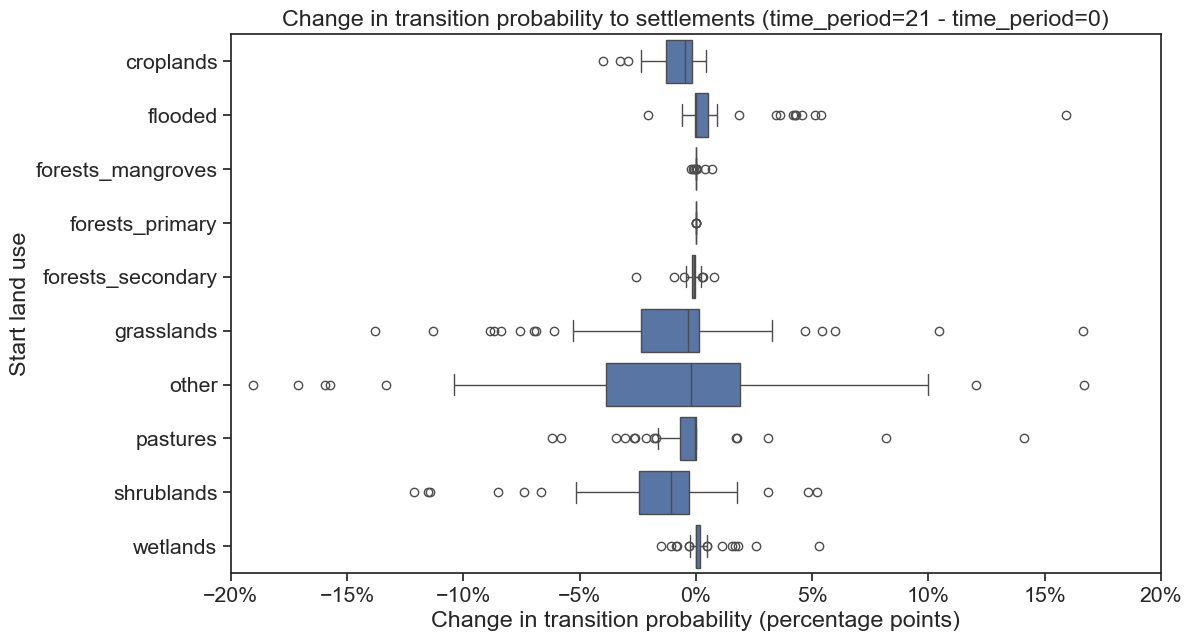

In [242]:
fig, ax = plt.subplots(figsize=(12, 7))
sns.boxplot(
    (
        arr_transition.sel(end="settlements", time_period=21)
        - arr_transition.sel(end="settlements", time_period=0)
    )
    .drop_sel(start="settlements")
    .to_dataframe()
    .reset_index(),
    x="transition_probability",
    y="start",
)
ax.set_xlim(-0.2, 0.2)
ax.set_xlabel("Change in transition probability (percentage points)")
ax.set_ylabel("Start land use")
ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
_ = ax.set_title(
    "Change in transition probability to settlements (time_period=21 - time_period=0)"
)

And the evolution of probability means. To facilitate visualization, we smooth the curves using a 5-year rolling window.

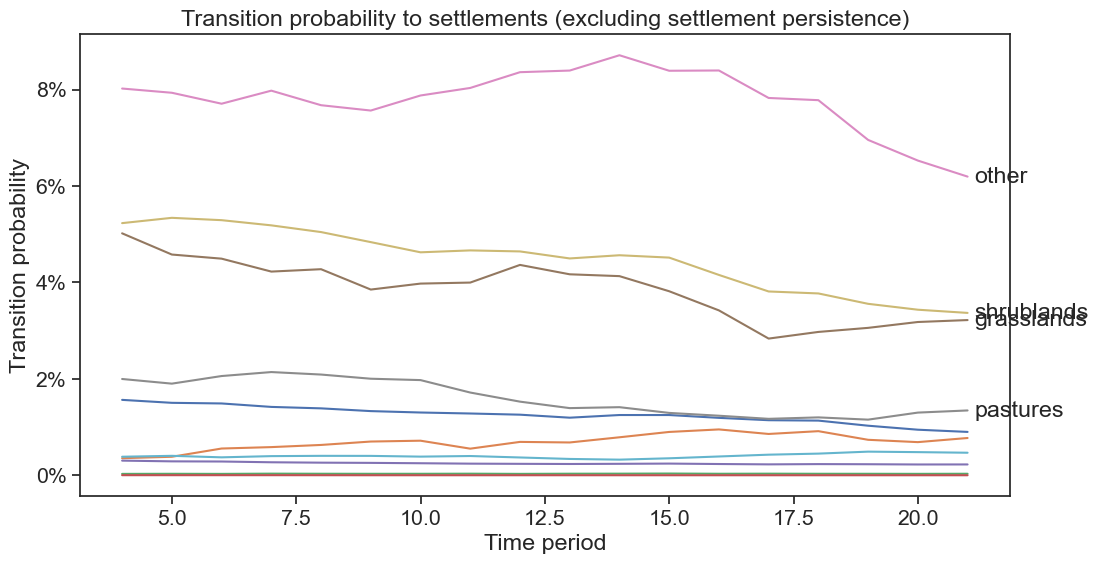

In [243]:
sns.set_theme(font_scale=1.4, style="ticks")
fig, ax = plt.subplots(figsize=(12, 6))
sns.lineplot(
    arr_transition.sel(end="settlements")
    .drop_sel(start="settlements")
    .rolling({"time_period": 5})
    .mean()
    .to_dataframe()
    .reset_index(),
    x="time_period",
    y="transition_probability",
    hue="start",
    ax=ax,
    legend=False,
    errorbar=None,
    estimator="mean",
)

for label in ["other", "shrublands", "grasslands", "pastures"]:
    ax.annotate(
        label,
        xy=(
            arr_transition.time_period[-1],
            arr_transition.sel(end="settlements", start=label)
            .rolling({"time_period": 5})
            .mean()
            .mean(dim="city")
            .to_dataframe()
            .reset_index()
            .iloc[-1]["transition_probability"],
        ),
        xytext=(5, 0),
        textcoords="offset points",
        va="center",
    )

ax.set_xlabel("Time period")
ax.set_ylabel("Transition probability")
ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1, decimals=0))
_ = ax.set_title(
    "Transition probability to settlements (excluding settlement persistence)"
)